## **EJERCICIO 1: Cambio Climático y Extensión del Hielo Marino**<p>

Queremos responder a la pregunta: ¿Ha habido una disminución en la cantidad de hielo en los últimos años?

Para ello utilizaremos las mediciones de la extensión del hielo marino del [Centro Nacional de Datos de Nieve y Hielo](https://nsidc.org).

Realizaremos los siguientes pasos de procesamiento:

- Debemos leer y limpiar los datos.
- Para calcular la tendencia en un intervalo de tiempo dado (mes), necesitamos normalizar los datos.
- Estos valores pueden ser graficados para toda la serie temporal o para meses específicos.
- Podemos calcular la tendencia como una regresión lineal simple (OLS) y evaluarla cuantitativamente.
- También podemos estimar el valor de la extensión para 2025.

Objetivo: Predecir extent para 2025

In [ ]:
# Load the data and show the info and contents:
import pandas as pd
ice = pd.read_csv('files/ch06/SeaIce.txt',delim_whitespace=True)
print('shape: {}'.format(ice.shape))
ice.head() 

shape: (424, 6)


C:\Users\emartin4\AppData\Local\Temp\ipykernel_22204\2218391646.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ice = pd.read_csv('files/ch06/SeaIce.txt',delim_whitespace=True)


,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92


In [ ]:
ice

,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92
...,...,...,...,...,...,...
419,2009,12,Goddard,N,12.51,10.25
420,2010,12,Goddard,N,12.02,10.08
421,2011,12,Goddard,N,12.40,10.28
422,2012,12,Goddard,N,12.20,10.11


In [ ]:
ice['data_type'].value_counts()

data_type
Goddard    409
NRTSI-G     13
-9999        2
Name: count, dtype: int64

In [ ]:
ice[ice.data_type == "-9999"]

,year,mo,data_type,region,extent,area
9,1988,1,-9999,N,-9999.0,-9999.0
397,1987,12,-9999,N,-9999.0,-9999.0


In [ ]:
# Quitamos los outliers de -9999
ice = ice[ice.data_type != "-9999"]
ice

,year,mo,data_type,region,extent,area
0,1979,1,Goddard,N,15.54,12.33
1,1980,1,Goddard,N,14.96,11.85
2,1981,1,Goddard,N,15.03,11.82
3,1982,1,Goddard,N,15.26,12.11
4,1983,1,Goddard,N,15.10,11.92
...,...,...,...,...,...,...
419,2009,12,Goddard,N,12.51,10.25
420,2010,12,Goddard,N,12.02,10.08
421,2011,12,Goddard,N,12.40,10.28
422,2012,12,Goddard,N,12.20,10.11


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
ice['data_type_int'] = le.fit_transform(ice['data_type'])
ice

C:\Users\emartin4\AppData\Local\Temp\ipykernel_22204\3492807223.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ice['data_type_int'] = le.fit_transform(ice['data_type'])


,year,mo,data_type,region,extent,area,data_type_int
0,1979,1,Goddard,N,15.54,12.33,0
1,1980,1,Goddard,N,14.96,11.85,0
2,1981,1,Goddard,N,15.03,11.82,0
3,1982,1,Goddard,N,15.26,12.11,0
4,1983,1,Goddard,N,15.10,11.92,0
...,...,...,...,...,...,...,...
419,2009,12,Goddard,N,12.51,10.25,0
420,2010,12,Goddard,N,12.02,10.08,0
421,2011,12,Goddard,N,12.40,10.28,0
422,2012,12,Goddard,N,12.20,10.11,0


In [ ]:
# Quitamos las que no son numéricas o las que no nos sirven (region), tiene valor unico
ice = ice.drop(columns=['data_type', 'region'])
ice

,year,mo,extent,area,data_type_int
0,1979,1,15.54,12.33,0
1,1980,1,14.96,11.85,0
2,1981,1,15.03,11.82,0
3,1982,1,15.26,12.11,0
4,1983,1,15.10,11.92,0
...,...,...,...,...,...
419,2009,12,12.51,10.25,0
420,2010,12,12.02,10.08,0
421,2011,12,12.40,10.28,0
422,2012,12,12.20,10.11,0


Para calcular la anomalía en un intervalo de tiempo dado, podemos calcular la media para ese intervalo de tiempo (usando el período de 1981 a 2010 para la extensión media), antes de la limpieza de datos.

In [ ]:
# Your code goes here
X = ice[['year', 'mo', 'area', 'data_type_int']].values
y = ice.extent.values

In [ ]:
X

array([[1.979e+03, 1.000e+00, 1.233e+01, 0.000e+00],
       [1.980e+03, 1.000e+00, 1.185e+01, 0.000e+00],
       [1.981e+03, 1.000e+00, 1.182e+01, 0.000e+00],
       ...,
       [2.011e+03, 1.200e+01, 1.028e+01, 0.000e+00],
       [2.012e+03, 1.200e+01, 1.011e+01, 0.000e+00],
       [2.013e+03, 1.200e+01, 1.048e+01, 1.000e+00]])

In [ ]:
y

array([15.54, 14.96, 15.03, 15.26, 15.1 , 14.61, 14.86, 15.02, 15.2 ,
       15.12, 14.95, 14.46, 14.72, 15.08, 14.82, 14.62, 14.21, 14.47,
       14.81, 14.47, 14.41, 14.31, 14.45, 14.46, 14.03, 13.66, 13.6 ,
       13.77, 14.05, 14.08, 13.8 , 13.57, 13.77, 13.78, 13.73, 16.31,
       15.98, 15.65, 16.06, 16.02, 15.32, 15.67, 15.89, 16.11, 15.61,
       15.56, 15.56, 15.26, 15.5 , 15.73, 15.61, 15.24, 15.17, 15.52,
       15.77, 15.37, 15.18, 15.27, 15.36, 15.25, 14.93, 14.36, 14.42,
       14.53, 15.01, 14.85, 14.59, 14.38, 14.59, 14.69, 14.44, 16.45,
       16.13, 15.61, 16.15, 16.1 , 15.62, 16.06, 16.08, 15.95, 16.13,
       15.52, 15.88, 15.5 , 15.47, 15.88, 15.58, 15.32, 15.13, 15.58,
       15.66, 15.4 , 15.27, 15.61, 15.44, 15.49, 15.05, 14.74, 14.43,
       14.65, 15.22, 15.14, 15.11, 14.58, 15.24, 15.04, 15.46, 15.49,
       15.12, 15.57, 15.3 , 15.15, 15.34, 15.15, 15.33, 15.21, 14.44,
       14.68, 14.93, 14.7 , 15.18, 14.95, 14.59, 14.22, 14.59, 14.89,
       15.13, 14.63,

In [ ]:
ice.describe()

,year,mo,extent,area,data_type_int
count,422.000000,422.000000,422.000000,422.000000,422.000000
mean,1996.040284,6.500000,11.777583,9.287796,0.030806
std,10.222038,3.461872,3.120722,3.180044,0.172996
min,1978.000000,1.000000,3.630000,2.150000,0.000000
25%,1987.000000,3.250000,9.360000,6.382500,0.000000
50%,1996.000000,6.500000,12.395000,9.990000,0.000000
75%,2005.000000,9.750000,14.560000,12.227500,0.000000
max,2014.000000,12.000000,16.450000,13.840000,1.000000


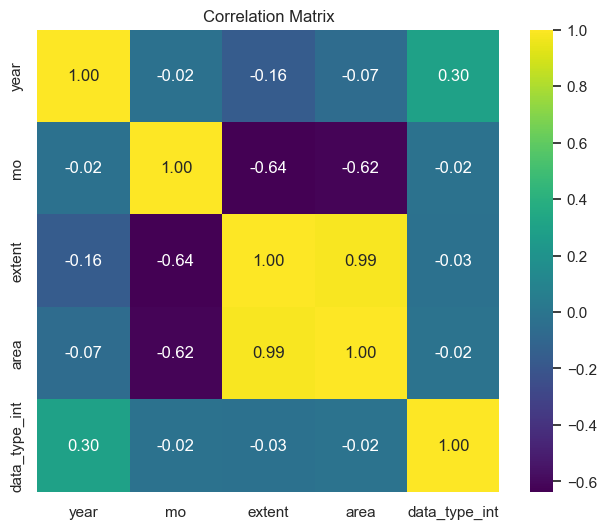

In [ ]:
correlation_matrix = ice.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', square=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

Vemos que area y extent están altamente correladas

C:\Users\emartin4\AppData\Local\Temp\ipykernel_22204\739125002.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


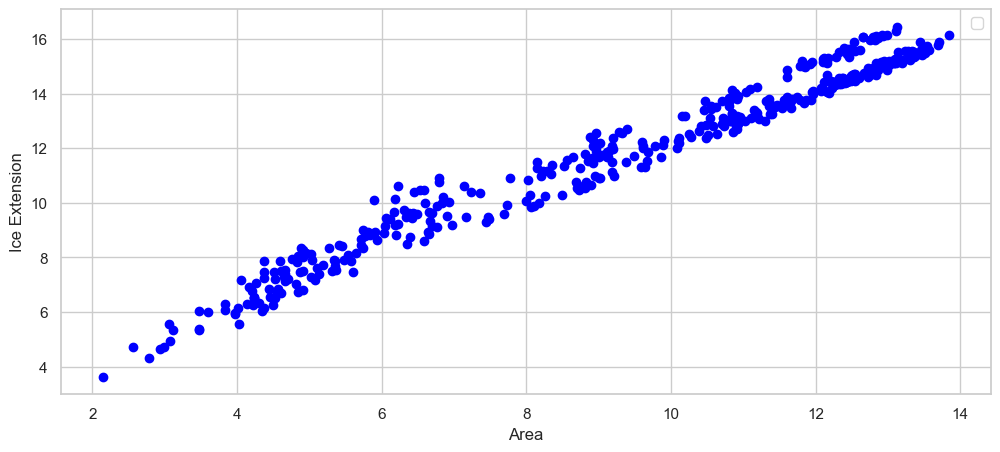

In [ ]:
plt.scatter(ice['area'], ice['extent'], color='blue')
plt.xlabel('Area')
plt.ylabel('Ice Extension')
plt.legend()
plt.show()

#### OLS

In [ ]:
# Your code goes here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(337, 4) (85, 4) (337,) (85,)


In [ ]:
X_train_df = pd.DataFrame(X_train, columns=['year', 'mo', 'area', 'data_type_int'])
X_test_df = pd.DataFrame(X_test, columns=['year', 'mo', 'area', 'data_type_int'])
X_train_df

,year,mo,area,data_type_int
0,1991.0,4.0,12.79,0.0
1,1987.0,9.0,5.60,0.0
2,1984.0,4.0,12.10,0.0
3,1981.0,4.0,12.16,0.0
4,1995.0,6.0,8.86,0.0
...,...,...,...,...
332,2011.0,5.0,10.41,0.0
333,2009.0,7.0,5.77,0.0
334,1987.0,7.0,6.84,0.0
335,1989.0,5.0,11.30,0.0


In [ ]:
ice

,year,mo,extent,area,data_type_int
0,1979,1,15.54,12.33,0
1,1980,1,14.96,11.85,0
2,1981,1,15.03,11.82,0
3,1982,1,15.26,12.11,0
4,1983,1,15.10,11.92,0
...,...,...,...,...,...
419,2009,12,12.51,10.25,0
420,2010,12,12.02,10.08,0
421,2011,12,12.40,10.28,0
422,2012,12,12.20,10.11,0


In [ ]:
import statsmodels.api as sm
#est = sm.OLS(y_train, X_train) # Creates an object OLS estimator

X_train_sm = sm.add_constant(X_train_df)
est = sm.OLS(y_train, X_train_sm) # Creates an object OLS estimator

est = est.fit()
est.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     4310.
Date:                Wed, 30 Oct 2024   Prob (F-statistic):          1.19e-284
Time:                        20:31:35   Log-Likelihood:                -195.16
No. Observations:                 337   AIC:                             400.3
Df Residuals:                     332   BIC:                             419.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            68.8768      4.911     14.026      0.000      59.217      78.536
year             -0.0328      0.002    -13.392      0.000      -0.038      -0.028
mo               -0.0397      0.009     -4.345      0.000      -0.058      -0.022
area              0.9352      0.010     95.269      0.000       0.916       0.955
data_type_int     0.2716      0.135      2.008      0.045       0.006       0.538
==============================================================================
Omnibus:                        1.271   Durbin-Watson:                   1.923
Prob(Omnibus):                  0.530   Jarque-Bera (JB):                1.362
Skew:                           0.138   Prob(JB):                        0.506
Kurtosis:                       2.855   Cond. No.                     4.14e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.14e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
# Realizamos predicciones sobre los datos de prueba
# y_pred = est.predict(X_train_sm)

X_test_sm = sm.add_constant(X_test_df)
y_pred = est.predict(X_test_sm)

# Evaluamos la performance del modelo con RMSE y R^2
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

#rmse = mean_squared_error(y_test, y_pred, squared=False)  # Raíz del error cuadrático medio
rmse = root_mean_squared_error(y_test, y_pred)  # Raíz del error cuadrático medio
r2 = r2_score(y_test, y_pred)  # R^2

print(f"RMSE: {rmse}")
print(f"R^2: {r2}")

RMSE: 0.3633339805225555
R^2: 0.9855080938083907


#### Predecir la extensión para 2025

In [ ]:
X_train_sm

,const,year,mo,area,data_type_int
0,1.0,1980.0,6.0,8.93,0.0
1,1.0,1991.0,2.0,13.15,0.0
2,1.0,1987.0,6.0,9.32,0.0
3,1.0,2009.0,11.0,8.05,0.0
4,1.0,1982.0,1.0,12.11,0.0
...,...,...,...,...,...
332,1.0,2002.0,10.0,6.20,0.0
333,1.0,1983.0,6.0,9.20,0.0
334,1.0,2007.0,4.0,11.75,0.0
335,1.0,1981.0,3.0,12.62,0.0


In [ ]:
# Crear un nuevo DataFrame para el año 2025
data_2025 =  pd.DataFrame({
            'const': 1,         
            'year': [2025],     
            'mo': [1],
            'area': [9.0], 
            'data_type_int': [0]
            })


ypred_2025 = est.predict(data_2025)
print(f'Predicción de la extensión del hielo marino para 2025: {ypred_2025[0]:.2f}')

Predicción de la extensión del hielo marino para 2025: 10.83


In [ ]:
preds = pd.DataFrame([y_test, y_pred.values]).T.rename(columns={0: "y_test", 1: "y_pred"})
preds["pred_error"] = preds["y_pred"] - preds["y_test"] 
preds

,y_test,y_pred,pred_error
0,15.40,15.699553,0.299553
1,6.13,7.159358,1.029358
2,6.30,6.663181,0.363181
3,14.08,14.086488,0.006488
4,12.10,11.600676,-0.499324
...,...,...,...
80,13.17,13.435408,0.265408
81,6.68,7.417911,0.737911
82,6.50,7.352767,0.852767
83,15.18,15.365815,0.185815
